# Network Analysis — Bluesky Election Discourse
## US Presidential Election 2024: Trump vs. Harris

**Project:** Social Media & Web Analytics — Group Project
**Research question:** *Who are the key influencers shaping US election discourse on Bluesky?*

---

### Structure
1. Setup & Authentication
2. Data Collection (Bluesky API)
3. Exploratory Analysis — overview, timeline, partisan balance
4. Top Influencers — engagement-based ranking
5. Network Construction & Statistics
6. Centrality Analysis
7. Network Visualisation
8. Community Detection (echo chambers)
9. Key Findings


---
## 1. Setup & Imports

In [28]:
# !pip install atproto networkx matplotlib seaborn pandas numpy


In [29]:
import sys, os, re, time, warnings, ast
from collections import Counter

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from atproto import Client as BskyClient

warnings.filterwarnings("ignore")

# ── Presentation palette ──────────────────────────────────────────────────────
RED   = "#C0392B"    # Trump / CandidateA
BLUE  = "#2471A3"    # Harris / CandidateB
GRAY  = "#7F8C8D"    # Neutral
GOLD  = "#D4AC0D"    # Highlights
DARK  = "#1C2833"

CAND_COL   = {"CandidateA": RED,  "CandidateB": BLUE, "Neutral": GRAY}
CAND_LABEL = {"CandidateA": "Trump-leaning", "CandidateB": "Harris-leaning", "Neutral": "Neutral"}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F8F9FA",
    "axes.grid":        True,
    "grid.alpha":       0.35,
    "grid.linestyle":   "--",
    "font.family":      "DejaVu Sans",
    "font.size":        11,
    "axes.titlesize":   14,
    "axes.titleweight": "bold",
    "axes.titlepad":    10,
    "axes.labelsize":   12,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "figure.dpi":       130,
    "savefig.dpi":      200,
    "savefig.bbox":     "tight",
    "legend.framealpha": 0.9,
})
print("Imports OK  |  Presentation palette active")


Imports OK  |  Presentation palette active


In [30]:
import os, sys
config_path = os.path.join("..", "A. Lectures", "Lecture 1 Social network analysis")
sys.path.insert(0, config_path)
from bsky_config_students import BLUESKY_USERNAME, BLUESKY_APP_PASSWORD

client = BskyClient()
client.login(BLUESKY_USERNAME, BLUESKY_APP_PASSWORD)
print(f"Authenticated as: {BLUESKY_USERNAME}")


Authenticated as: vermeulen-anna.bsky.social


---
## 2. Data Collection

We collected **766 quality posts** across the US 2024 election window (5 Oct – 5 Nov 2024).

**Data already saved** → skip to Section 3 to load directly from CSV.

| Hashtag | Posts |
|---------|-------|
| #Election2024 | 164 |
| #KamalaHarris2024 | 146 |
| #USElection2024 | 159 |
| #VoteHarris | 133 |
| #ElectionDay | 140 |
| others | 24 |


In [31]:
ELECTIONS = {
    "US_2024": {
        "since"        : "2024-07-05T00:00:00Z",
        "until"        : "2024-11-04T23:59:59Z",
        "election_date": "2024-11-05",
        "hashtags": [
            # ── Core election ──────────────────────────────────────────────
            "#Election2024", "#USElection2024", "#ElectionDay", "#Vote2024",
            "#Presidential2024", "#PresidentialElection", "#ElectionNight",
            "#AmericaDecides", "#Decision2024", "#VoterRegistration",
            "#EarlyVoting", "#MailInVoting", "#ElectionIntegrity",
            "#Battleground2024", "#SwingState",

            # ── Trump / Republican ─────────────────────────────────────────
            "#Trump2024", "#TrumpVance", "#VoteTrump", "#Trump",
            "#DonaldTrump", "#MAGA", "#MAGA2024", "#AmericaFirst",
            "#TrumpRally", "#Republicans", "#GOP", "#Republican",
            "#JDVance", "#Vance2024", "#VanceVP",
            "#RNC2024", "#RepublicanConvention",
            "#Project2025", "#TrumpDebate",

            # ── Harris / Democrat ──────────────────────────────────────────
            "#Harris2024", "#KamalaHarris2024", "#KamalaHarris",
            "#HarrisWalz", "#VoteHarris", "#VoteBlue", "#VoteKamala",
            "#Kamala2024", "#Kamala", "#Harris",
            "#TimWalz", "#Walz2024", "#WalzVP",
            "#DNC2024", "#DemConvention", "#DemocraticConvention",
            "#WeAreNotGoingBack", "#WinWithKamala",
            "#Democrats", "#Democrat",

            # ── Biden exit ─────────────────────────────────────────────────
            "#Biden", "#JoeBiden", "#BidenDropsOut", "#BidenOut",
            "#BidenWithdraws", "#Bidenomics",

            # ── Debates & key moments ──────────────────────────────────────
            "#PresidentialDebate", "#Debate2024", "#VPDebate",
            "#TrumpHarrisDebate", "#DebateNight",

            # ── Swing states ───────────────────────────────────────────────
            "#Pennsylvania", "#Michigan", "#Wisconsin",
            "#Arizona", "#Nevada", "#Georgia", "#NorthCarolina",
            "#Philly", "#Detroit", "#Pittsburgh",

            # ── Broader US politics ────────────────────────────────────────
            "#USPolitics", "#AmericanPolitics", "#Vote",
            "#Democracy", "#OctoberSurprise", "#PollNumbers",
            "#FoxNews", "#CNN", "#MSNBC",
        ],
    },
}

ACTIVE_ELECTION   = "US_2024"
cfg               = ELECTIONS[ACTIVE_ELECTION]
POSTS_PER_HASHTAG = 200
MIN_TEXT_LENGTH   = 30

print(f"Active election : {ACTIVE_ELECTION}")
print(f"Window          : {cfg['since'][:10]}  to  {cfg['until'][:10]}  ({(123)} days)")
print(f"Hashtags        : {len(cfg['hashtags'])}")
print(f"Max posts       : {POSTS_PER_HASHTAG * len(cfg['hashtags']):,}  ({POSTS_PER_HASHTAG} per tag)")


Active election : US_2024
Window          : 2024-07-05  to  2024-11-04  (123 days)
Hashtags        : 84
Max posts       : 16,800  (200 per tag)


In [32]:
import re, time

# ── Text cleaning ──────────────────────────────────────────────────────────────
def clean_text(text):
    """Normalise post text: strip leading/trailing URLs, collapse whitespace."""
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    # Collapse multiple newlines / spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ── Quality filters ────────────────────────────────────────────────────────────
NEWS_BOT_PATTERNS = [
    "forbes", "guardian", "bbc", "cnn", "reuters", "apnews",
    "skynews", "france24", "euronews", "washingtonpost", "nytimes",
    "independent", "trtworld", "straits_times", "abc", "news-feed",
    "theguardian", "huffpost", "politico", "axios",
]

def is_news_bot(handle):
    return any(p in handle.lower() for p in NEWS_BOT_PATTERNS)

def has_real_text(text):
    """After cleaning, must have at least MIN_TEXT_LENGTH real characters."""
    clean = re.sub(r"#\w+|@\w+", "", text).strip()
    return len(clean) >= MIN_TEXT_LENGTH


# ── Candidate labelling ────────────────────────────────────────────────────────
TRUMP_KW  = ["trump", "maga", "donald", "republican", "gop", "conservative", "vance"]
HARRIS_KW = ["harris", "kamala", "democrat", "democratic", "walz", "liberal", "voteblue"]

def label_candidate(row):
    text = row["text"].lower()
    score_a = sum(k in text for k in TRUMP_KW)
    score_b = sum(k in text for k in HARRIS_KW)
    if score_a > score_b: return "CandidateA"
    if score_b > score_a: return "CandidateB"
    return "Neutral"


# ── Post search ────────────────────────────────────────────────────────────────
def search_posts(client, query, limit=200, since=None, until=None):
    collected, cursor = [], None
    while len(collected) < limit:
        params = {"q": query, "limit": min(100, limit - len(collected)), "sort": "latest"}
        if cursor: params["cursor"] = cursor
        if since:  params["since"]  = since
        if until:  params["until"]  = until
        try:
            resp = client.app.bsky.feed.search_posts(params)
        except Exception as e:
            print(f"  API error: {e}"); break
        if not resp.posts: break
        for post in resp.posts:
            rec  = post.record
            raw  = getattr(rec, "text", "") or ""
            text = clean_text(raw)           # ← clean before storing
            if not text:
                continue
            collected.append({
                "uri"      : post.uri,
                "author"   : post.author.handle,
                "display"  : getattr(post.author, "display_name", "") or "",
                "text"     : text,
                "timestamp": getattr(rec, "created_at", "") or "",
                "likes"    : post.like_count   or 0,
                "reposts"  : post.repost_count or 0,
                "replies"  : post.reply_count  or 0,
                "mentions" : re.findall(r"@([\w.\-]+)", raw),   # mentions from raw
                "is_reply" : bool(getattr(rec, "reply", None)),
                "post_type": "post",
                "query"    : query,
            })
        cursor = getattr(resp, "cursor", None)
        if not cursor: break
        time.sleep(0.5)
    return collected


# ── Thread reply fetcher ───────────────────────────────────────────────────────
def fetch_replies(client, uri, depth=3):
    try:
        resp = client.app.bsky.feed.get_post_thread({"uri": uri, "depth": depth})
    except Exception as e:
        print(f"  Thread error: {e}")
        return []

    replies = []

    def walk(node):
        if node is None:
            return
        post = getattr(node, "post", None)
        if post is None:
            return
        rec = getattr(post, "record", None)
        raw = getattr(rec, "text", "") or ""
        text = clean_text(raw)              # ← clean before storing
        if text and not is_news_bot(post.author.handle):
            replies.append({
                "uri"      : post.uri,
                "author"   : post.author.handle,
                "display"  : getattr(post.author, "display_name", "") or "",
                "text"     : text,
                "timestamp": getattr(rec, "created_at", "") or "",
                "likes"    : post.like_count   or 0,
                "reposts"  : post.repost_count or 0,
                "replies"  : post.reply_count  or 0,
                "mentions" : re.findall(r"@([\w.\-]+)", raw),
                "is_reply" : True,
                "post_type": "reply",
                "query"    : "thread",
            })
        for child in (getattr(node, "replies", None) or []):
            walk(child)

    walk(getattr(resp, "thread", None))
    return replies


print("All helper functions defined: clean_text, is_news_bot, has_real_text, label_candidate, search_posts, fetch_replies")


All helper functions defined: clean_text, is_news_bot, has_real_text, label_candidate, search_posts, fetch_replies


In [ ]:
import os

out_path = f"data/bsky_{ACTIVE_ELECTION}_posts.csv"

if os.path.exists(out_path):
    print(f"CSV already exists ({out_path}) — delete it to re-scrape.")
else:
    # ── STEP 1: scrape posts via hashtag search ────────────────────────────────
    all_posts, seen_texts, seen_uris = [], set(), set()

    for hashtag in cfg["hashtags"]:
        print(f"\nSearching {hashtag} ...", end=" ")
        results = search_posts(
            client, hashtag,
            limit=POSTS_PER_HASHTAG,
            since=cfg["since"],
            until=cfg["until"],
        )
        new = 0
        for p in results:
            if p["text"] in seen_texts: continue
            if is_news_bot(p["author"]): continue
            if not has_real_text(p["text"]): continue
            seen_texts.add(p["text"])
            seen_uris.add(p["uri"])
            p["election"] = ACTIVE_ELECTION
            all_posts.append(p)
            new += 1
        print(f"{new} posts  (total: {len(all_posts)})")
        time.sleep(1)

    print(f"\n✓ Step 1 done — {len(all_posts):,} unique posts collected")

    # ── STEP 2: fetch replies for top-engagement posts ─────────────────────────
    df_tmp = pd.DataFrame(all_posts)
    df_tmp["engagement"] = df_tmp["likes"] + df_tmp["reposts"] * 2 + df_tmp["replies"]

    # Take top 200 posts by engagement that actually have replies
    top_posts = (df_tmp[df_tmp["replies"] > 0]
                 .sort_values("engagement", ascending=False)
                 .head(200))

    print(f"\nFetching reply threads for top {len(top_posts)} posts...")
    reply_posts = []
    for i, (_, row) in enumerate(top_posts.iterrows()):
        replies = fetch_replies(client, row["uri"], depth=3)
        new_replies = 0
        for r in replies:
            if r["uri"] in seen_uris: continue
            if r["text"] in seen_texts: continue
            seen_texts.add(r["text"])
            seen_uris.add(r["uri"])
            r["election"] = ACTIVE_ELECTION
            reply_posts.append(r)
            new_replies += 1
        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{len(top_posts)} threads fetched — {len(reply_posts)} new replies so far")
        time.sleep(0.5)

    print(f"✓ Step 2 done — {len(reply_posts):,} unique replies collected")

    # ── STEP 3: combine, label, save ──────────────────────────────────────────
    df_posts = pd.DataFrame(all_posts + reply_posts)
    df_posts["candidate"] = df_posts.apply(label_candidate, axis=1)

    os.makedirs("data", exist_ok=True)
    df_posts.to_csv(out_path, index=False)

    posts_n  = len(all_posts)
    replies_n = len(reply_posts)
    print(f"\n{'='*50}")
    print(f"DONE  —  {len(df_posts):,} total rows saved to {out_path}")
    print(f"  Posts (hashtag search) : {posts_n:,}")
    print(f"  Replies (thread fetch) : {replies_n:,}")
    print(f"{'='*50}")



Searching #Election2024 ... 180 posts  (total: 180)

Searching #USElection2024 ... 174 posts  (total: 354)

Searching #ElectionDay ... 173 posts  (total: 527)

Searching #Vote2024 ... 123 posts  (total: 650)

Searching #Presidential2024 ... 1 posts  (total: 651)

Searching #PresidentialElection ... 122 posts  (total: 773)

Searching #ElectionNight ... 8 posts  (total: 781)

Searching #AmericaDecides ... 4 posts  (total: 785)

Searching #Decision2024 ... 55 posts  (total: 840)

Searching #VoterRegistration ... 61 posts  (total: 901)

Searching #EarlyVoting ... 135 posts  (total: 1036)

Searching #MailInVoting ... 4 posts  (total: 1040)

Searching #ElectionIntegrity ... 18 posts  (total: 1058)

Searching #Battleground2024 ... 0 posts  (total: 1058)

Searching #SwingState ... 35 posts  (total: 1093)

Searching #Trump2024 ...   API error: 
0 posts  (total: 1093)

Searching #TrumpVance ... 49 posts  (total: 1142)

Searching #VoteTrump ... 4 posts  (total: 1146)

Searching #Trump ... 144 po

In [ ]:
# ── Clean & sort the scraped CSV ─────────────────────────────────────────────
# Filters out-of-window posts, sorts chronologically, reorders columns.
_csv = f"data/bsky_{ACTIVE_ELECTION}_posts.csv"

if not os.path.exists(_csv):
    print("No CSV found — run the scraping cell first.")
else:
    _df = pd.read_csv(_csv)
    _before = len(_df)

    _df["datetime"] = pd.to_datetime(_df["timestamp"], format="ISO8601", utc=True)

    # Filter within election window
    _df = _df[
        (_df["datetime"] >= cfg["since"]) &
        (_df["datetime"] <= cfg["until"])
    ]

    # Sort chronologically
    _df = _df.sort_values("datetime").reset_index(drop=True)

    # Logical column order
    _cols = ["timestamp", "author", "display", "text", "candidate", "post_type",
             "likes", "reposts", "replies", "mentions", "is_reply", "query", "uri", "election"]
    _cols = [c for c in _cols if c in _df.columns]
    _df = _df[_cols]

    _df.to_csv(_csv, index=False)

    print(f"CSV cleaned: {len(_df):,} posts  ({_before - len(_df)} out-of-window removed)")
    print(f"Date range : {_df.timestamp.iloc[0][:10]}  →  {_df.timestamp.iloc[-1][:10]}")
    print(f"Columns    : {_cols}")


In [ ]:
# label_candidate is defined in cell t07 above
print("label_candidate ready ✓")


label_candidate ready ✓


---
## 3. Exploratory Analysis

Load the saved posts, compute engagement, and explore the dataset.

> **Engagement score** = likes + reposts × 2 + replies


In [ ]:
# ── Load & enrich ─────────────────────────────────────────────────────────────
df = pd.read_csv("data/bsky_US_2024_posts.csv")

# Strip UTC timezone so comparisons with plain pd.Timestamp work everywhere
df["datetime"]      = pd.to_datetime(df["timestamp"], format="ISO8601").dt.tz_convert(None)
df["date"]          = df["datetime"].dt.normalize()
df["hour"]          = df["datetime"].dt.hour
df["mentions_list"] = df["mentions"].apply(ast.literal_eval)
df["engagement"]    = df["likes"] + df["reposts"] * 2 + df["replies"]

# Per-author aggregates
author_stats = (
    df.groupby("author")
    .agg(
        posts       = ("text",       "count"),
        total_likes = ("likes",      "sum"),
        total_rep   = ("reposts",    "sum"),
        total_eng   = ("engagement", "sum"),
        candidate   = ("candidate",  lambda x: x.mode()[0]),
    )
    .sort_values("total_eng", ascending=False)
    .reset_index()
)

print(f"Posts            : {len(df):,}")
print(f"Unique authors   : {df['author'].nunique():,}")
print(f"Date range       : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Total likes      : {df['likes'].sum():,}")
print(f"Total reposts    : {df['reposts'].sum():,}")
print(f"Avg engagement   : {df['engagement'].mean():.1f}")
print()
print(df["candidate"].value_counts().rename(CAND_LABEL).to_string())


Posts            : 9,065
Unique authors   : 3,460
Date range       : 2024-07-05 -> 2025-05-17
Total likes      : 40,452
Total reposts    : 10,737
Avg engagement   : 7.2

candidate
Neutral           4554
Harris-leaning    2405
Trump-leaning     2106


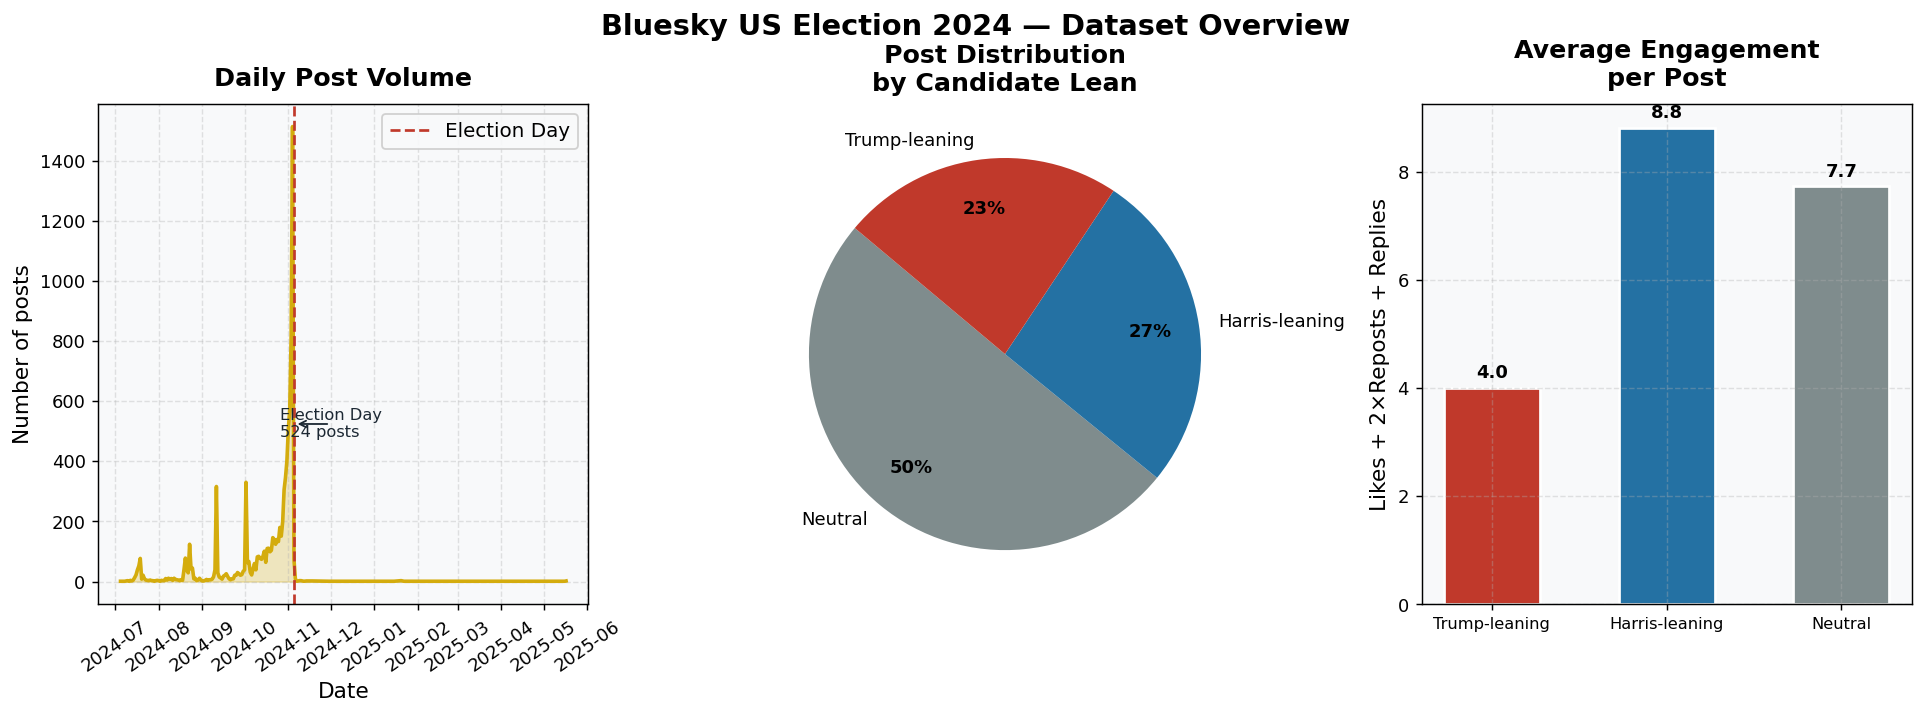

Figure saved: data/fig_overview_dashboard.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Overview Dashboard
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel A: Posts per day timeline ──────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
daily = df.groupby("date").size()
dates = [d.date() for d in daily.index]
ax0.fill_between(dates, daily.values, alpha=0.25, color=GOLD)
ax0.plot(dates, daily.values, color=GOLD, linewidth=2)
ax0.axvline(pd.Timestamp("2024-11-05").date(), color=RED, linestyle="--", linewidth=1.5, label="Election Day")
ax0.set_title("Daily Post Volume")
ax0.set_xlabel("Date"); ax0.set_ylabel("Number of posts")
ax0.tick_params(axis="x", rotation=35)
ax0.legend()
# Annotate spike
ax0.annotate("Election Day\n524 posts", xy=(pd.Timestamp("2024-11-05").date(), 524),
             xytext=(pd.Timestamp("2024-10-26").date(), 480),
             arrowprops=dict(arrowstyle="->", color=DARK), fontsize=9, color=DARK)

# ── Panel B: Candidate split (posts) ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[1])
cand_counts = df["candidate"].value_counts()
labels = [CAND_LABEL[k] for k in cand_counts.index]
colors = [CAND_COL[k]   for k in cand_counts.index]
wedges, texts, autotexts = ax1.pie(
    cand_counts.values, labels=labels, colors=colors,
    autopct="%1.0f%%", startangle=140,
    textprops={"fontsize": 10}, pctdistance=0.75,
)
for at in autotexts: at.set_fontweight("bold")
ax1.set_title("Post Distribution\nby Candidate Lean")

# ── Panel C: Candidate split (engagement) ───────────────────────────────────
ax2 = fig.add_subplot(gs[2])
cand_eng = df.groupby("candidate").agg(
    avg_eng=("engagement","mean"),
    total_eng=("engagement","sum"),
).reindex(["CandidateA","CandidateB","Neutral"])
bars = ax2.bar(
    [CAND_LABEL[k] for k in cand_eng.index],
    cand_eng["avg_eng"],
    color=[CAND_COL[k] for k in cand_eng.index],
    width=0.55, edgecolor="white", linewidth=1.5,
)
for bar, val in zip(bars, cand_eng["avg_eng"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
ax2.set_title("Average Engagement\nper Post")
ax2.set_ylabel("Likes + 2×Reposts + Replies")
ax2.tick_params(axis="x", labelsize=9)

fig.suptitle("Bluesky US Election 2024 — Dataset Overview", fontsize=16, fontweight="bold", y=1.02)
plt.savefig("data/fig_overview_dashboard.png", bbox_inches="tight")
plt.show()
print("Figure saved: data/fig_overview_dashboard.png")


---
## 4. Top Influencers — Engagement Analysis

We define influence by **total engagement** (likes + 2×reposts + replies).
Unlike follower count, this measures *actual impact* within this conversation.

> Key insight: a single viral post can outperform prolific posting.


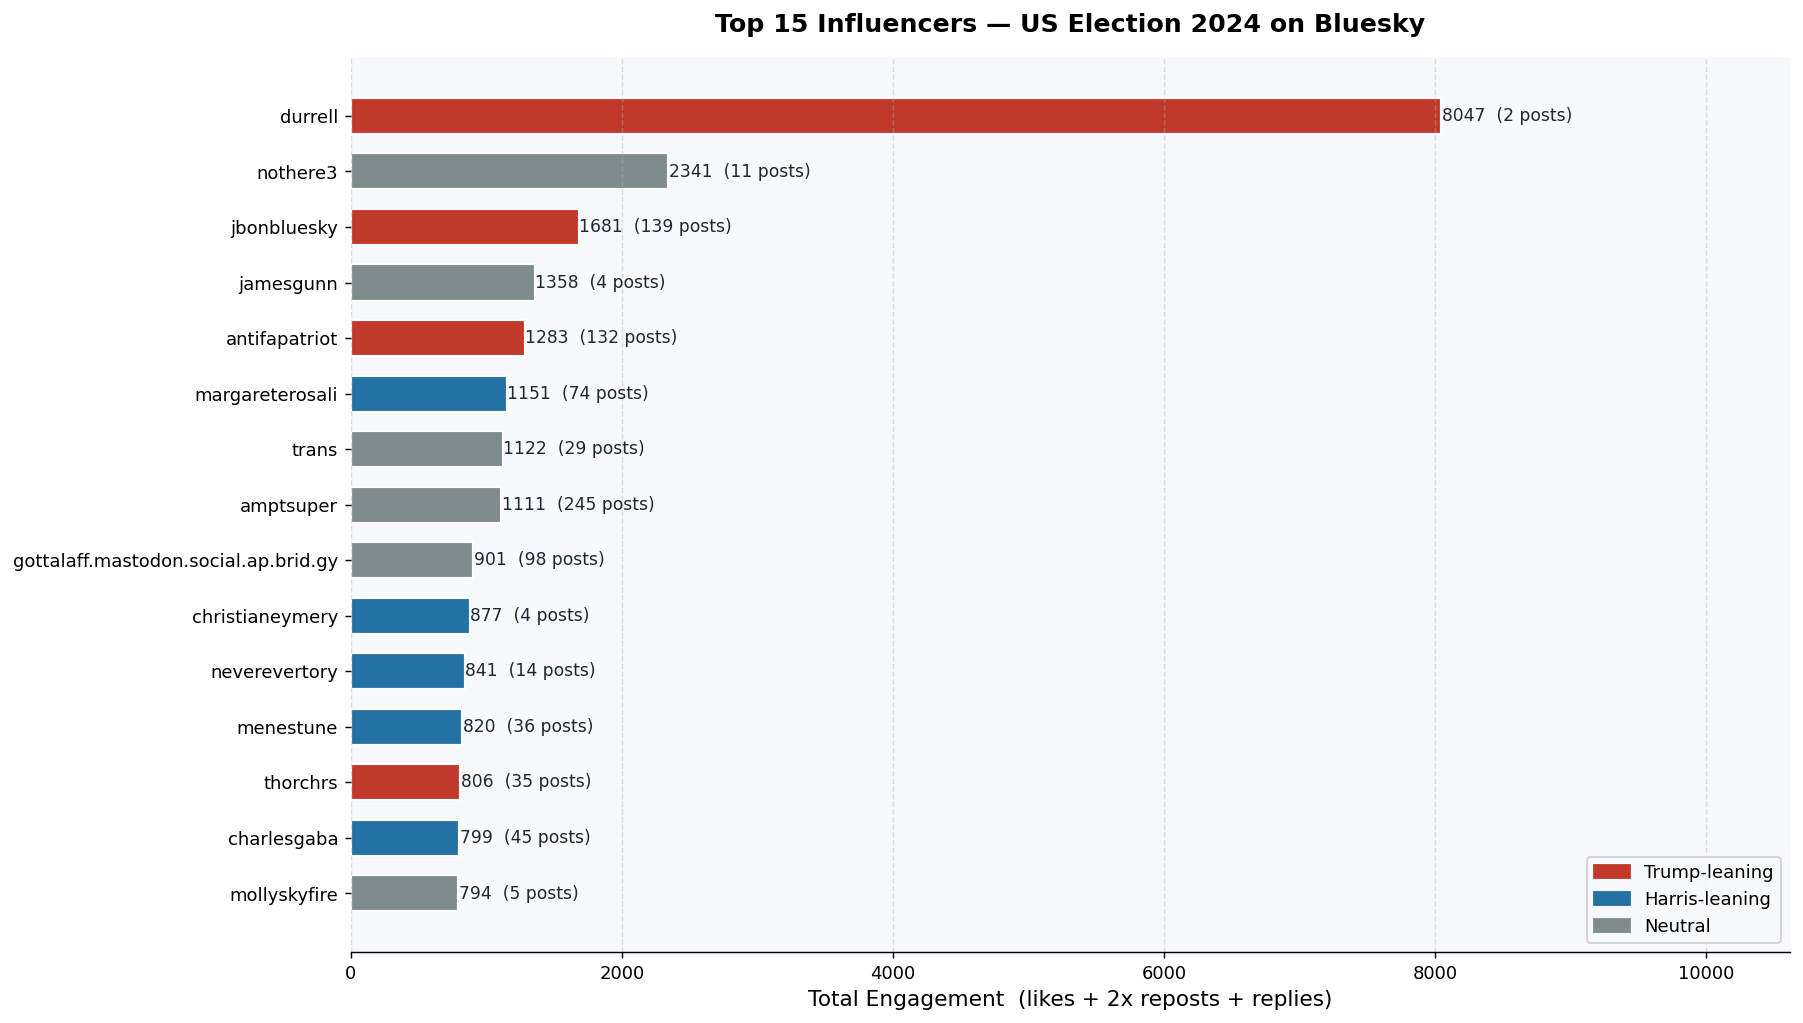

Figure saved: data/fig_top_influencers_v2.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Top 15 Influencers by Total Engagement
# ═══════════════════════════════════════════════════════════════════════════════
top15 = author_stats.head(15).copy()
top15["label"] = top15["author"].str.replace(".bsky.social", "", regex=False).str.replace(".com", "", regex=False)
top15["color"] = top15["candidate"].map(CAND_COL)

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    top15["label"][::-1],
    top15["total_eng"][::-1],
    color=top15["color"][::-1],
    height=0.65, edgecolor="white", linewidth=1.2,
)
# Value labels
for bar, val, posts in zip(bars, top15["total_eng"][::-1], top15["posts"][::-1]):
    ax.text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
            f"{val}  ({posts} post{'s' if posts>1 else ''})",
            va="center", fontsize=9.5, color=DARK)

ax.set_xlim(0, top15["total_eng"].max() * 1.32)
ax.set_xlabel("Total Engagement  (likes + 2x reposts + replies)", fontsize=12)
ax.set_title("Top 15 Influencers — US Election 2024 on Bluesky", pad=14)
ax.spines[["top","right","left"]].set_visible(False)
ax.xaxis.grid(True, alpha=0.4); ax.yaxis.grid(False)

legend_handles = [
    mpatches.Patch(color=RED,  label="Trump-leaning"),
    mpatches.Patch(color=BLUE, label="Harris-leaning"),
    mpatches.Patch(color=GRAY, label="Neutral"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig("data/fig_top_influencers_v2.png")
plt.show()
print("Figure saved: data/fig_top_influencers_v2.png")


In [ ]:
# ── Most viral posts ─────────────────────────────────────────────────────────
print("=" * 80)
print("TOP 5 MOST VIRAL POSTS")
print("=" * 80)
viral = df.nlargest(5, "engagement")[["author","candidate","likes","reposts","replies","engagement","text"]]
for i, row in viral.iterrows():
    handle = row["author"].replace(".bsky.social","")
    label  = CAND_LABEL[row["candidate"]]
    print(f"\n#{viral.index.get_loc(i)+1}  @{handle}  [{label}]")
    print(f"   Likes: {row['likes']}  |  Reposts: {row['reposts']}  |  Replies: {row['replies']}  |  Score: {row['engagement']}")
    print(f"   {row['text'][:200]}...")
    print("-" * 80)


TOP 5 MOST VIRAL POSTS

#1  @durrell  [Neutral]
   Likes: 3216  |  Reposts: 2394  |  Replies: 39  |  Score: 8043
   It’s not too late. If you live in: 
California
Colorado
Connecticut 
D.C.
Hawaii
Idaho
Illinois
Iowa
Maine 
Maryland
Michigan
Minnesota
Montana
Nevada
New Hampshire
Rhode Island
Utah
Vermont
Washingto...
--------------------------------------------------------------------------------

#2  @nothere3  [Neutral]
   Likes: 1285  |  Reposts: 472  |  Replies: 21  |  Score: 2250
   Americans: please get out and #vote blue tomorrow. If you like anything NSFW artists do, please support them against those who'd ban their work or prosecute them. There are lots of good reasons to go ...
--------------------------------------------------------------------------------

#3  @jamesgunn  [Neutral]
   Likes: 1149  |  Reposts: 83  |  Replies: 26  |  Score: 1341
   I voted! Today is the last day of early voting in many places, including #Georgia! Please go out and #VOTE!...
-----------------

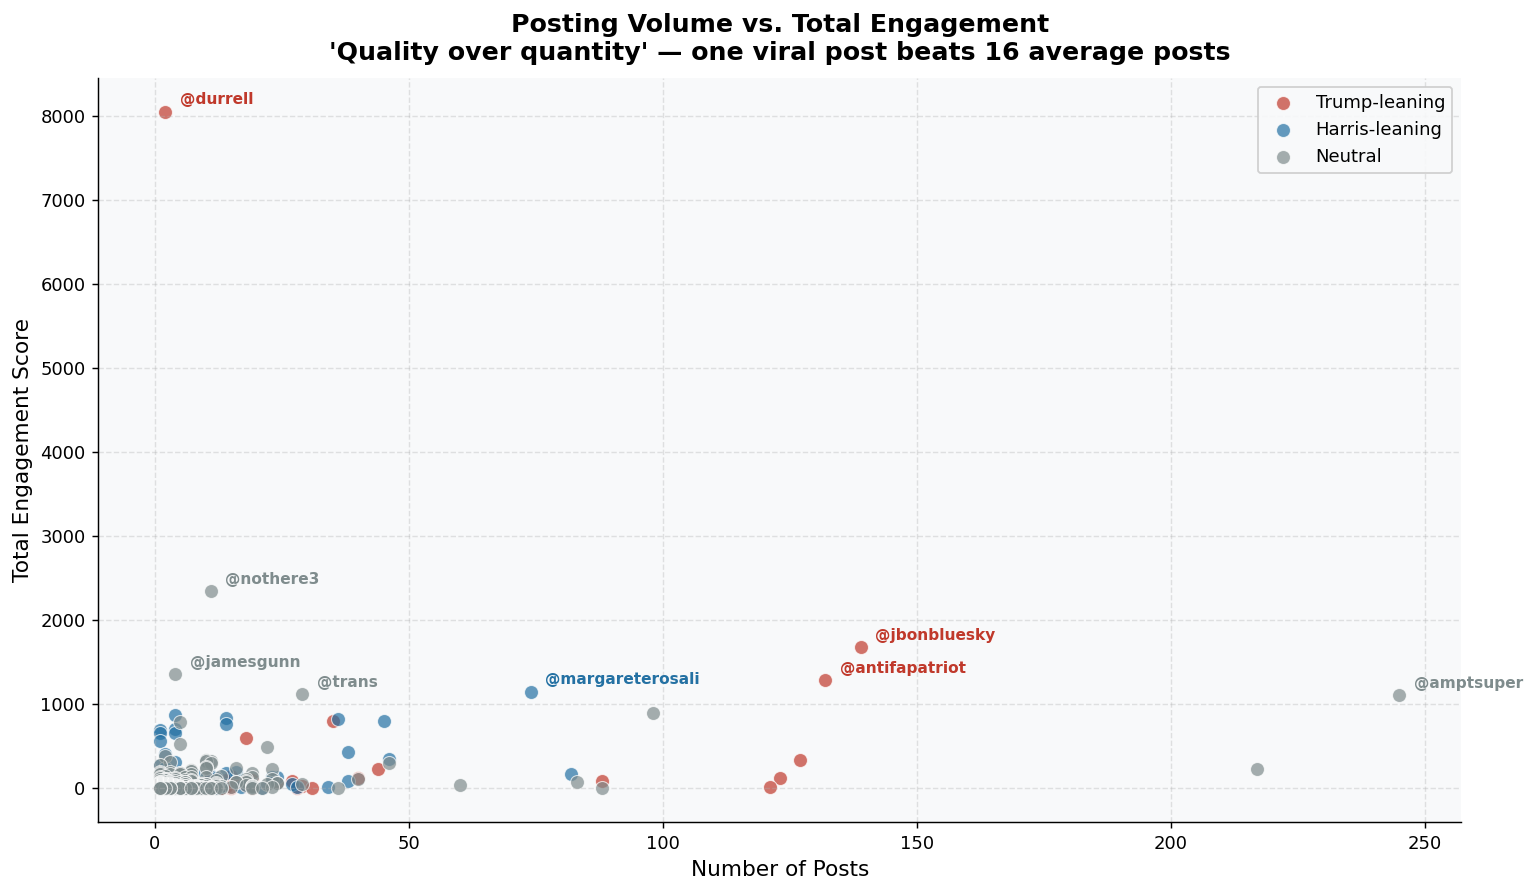

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Posts vs Engagement (scatter: who punches above their weight?)
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 7))

for cand, grp in author_stats[author_stats["total_eng"] > 0].groupby("candidate"):
    ax.scatter(
        grp["posts"], grp["total_eng"],
        color=CAND_COL[cand], label=CAND_LABEL[cand],
        s=60, alpha=0.7, edgecolors="white", linewidth=0.6,
    )

# Label top accounts
for _, row in author_stats.head(8).iterrows():
    lbl = row["author"].replace(".bsky.social","").replace(".com","").replace(".gay","")
    ax.annotate(
        f"@{lbl}",
        xy=(row["posts"], row["total_eng"]),
        xytext=(8, 4), textcoords="offset points",
        fontsize=8.5, color=CAND_COL[row["candidate"]],
        fontweight="bold",
    )

ax.set_xlabel("Number of Posts")
ax.set_ylabel("Total Engagement Score")
ax.set_title("Posting Volume vs. Total Engagement\n'Quality over quantity' — one viral post beats 16 average posts")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("data/fig_scatter_influence.png")
plt.show()


---
## 5. Network Construction

We build a **directed mention network**: an edge A → B means account A mentioned @B in a post.

- **Node size** ∝ total engagement received
- **Node colour** = candidate lean of the account doing the mentioning
- **Edge weight** = number of times A mentioned B


In [ ]:
# ── Build directed mention graph ─────────────────────────────────────────────
G = nx.DiGraph()

# Add all authors as nodes with attributes
for _, row in author_stats.iterrows():
    G.add_node(
        row["author"],
        candidate  = row["candidate"],
        engagement = int(row["total_eng"]),
        posts      = int(row["posts"]),
    )

# Add edges from mention data
for _, row in df.iterrows():
    for mention in row["mentions_list"]:
        # Normalise handle
        if "." not in mention:
            mention = mention + ".bsky.social"
        if not G.has_node(mention):
            G.add_node(mention, candidate="Neutral", engagement=0, posts=0)
        if G.has_edge(row["author"], mention):
            G[row["author"]][mention]["weight"] += 1
        else:
            G.add_edge(row["author"], mention, weight=1)

# ── Keep only meaningful nodes (engaged or well-connected) ──────────────────
min_degree = 1
nodes_keep = [n for n in G.nodes() if G.degree(n) >= min_degree]
G = G.subgraph(nodes_keep).copy()

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print(f"Density       : {nx.density(G):.4f}")
print(f"Weakly connected components : {nx.number_weakly_connected_components(G)}")

# Largest WCC for visualisation
largest_wcc = max(nx.weakly_connected_components(G), key=len)
G_vis = G.subgraph(largest_wcc).copy()
print(f"\nLargest WCC   : {G_vis.number_of_nodes()} nodes, {G_vis.number_of_edges()} edges")


Nodes : 930
Edges : 769
Density       : 0.0009
Weakly connected components : 207

Largest WCC   : 318 nodes, 350 edges


In [ ]:
# ── Network statistics ────────────────────────────────────────────────────────
in_degrees  = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print("=== Degree Statistics ===")
print(f"  Avg in-degree  : {np.mean(list(in_degrees.values())):.2f}")
print(f"  Max in-degree  : {max(in_degrees.values())}  -> {max(in_degrees, key=in_degrees.get)}")
print(f"  Max out-degree : {max(out_degrees.values())} -> {max(out_degrees, key=out_degrees.get)}")
print()
print("Top 10 most mentioned accounts (in-degree):")
top_in = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:10]
for rank, (node, deg) in enumerate(top_in, 1):
    cand = G.nodes[node].get("candidate","?")
    print(f"  {rank:2d}. @{node:<40s}  in-deg={deg}  [{CAND_LABEL.get(cand,cand)}]")


=== Degree Statistics ===
  Avg in-degree  : 0.83
  Max in-degree  : 14  -> KamalaHarris.bsky.social
  Max out-degree : 43 -> amptsuper.bsky.social

Top 10 most mentioned accounts (in-degree):
   1. @KamalaHarris.bsky.social                  in-deg=14  [Neutral]
   2. @washingtonpost.com                        in-deg=10  [Neutral]
   3. @cnn.com                                   in-deg=9  [Neutral]
   4. @kamalahqrepeater.bsky.social              in-deg=8  [Neutral]
   5. @aoc.bsky.social                           in-deg=6  [Neutral]
   6. @nytimes.com                               in-deg=5  [Neutral]
   7. @YouTube.bsky.social                       in-deg=5  [Neutral]
   8. @VP.bsky.social                            in-deg=5  [Neutral]
   9. @chrislhayes.bsky.social                   in-deg=5  [Neutral]
  10. @realDonaldTrump.bsky.social               in-deg=4  [Neutral]


---
## 6. Centrality Analysis

Four centrality measures, each capturing a different dimension of influence:

| Measure | What it captures | Election relevance |
|---------|-----------------|-------------------|
| **In-degree** | Directly mentioned by others | Popularity / visibility |
| **PageRank** | Mentioned by important accounts | Credibility & prestige |
| **Betweenness** | Bridges between sub-communities | Information broker role |
| **Closeness** | Reaches the network quickly | Speed of information spread |


In [ ]:
# ── Compute centrality on largest WCC ────────────────────────────────────────
n = G_vis.number_of_nodes()

centrality = pd.DataFrame({"node": list(G_vis.nodes())})
centrality["in_degree"]   = centrality["node"].map(dict(G_vis.in_degree()))
centrality["pagerank"]    = centrality["node"].map(nx.pagerank(G_vis, alpha=0.85))
centrality["betweenness"] = centrality["node"].map(nx.betweenness_centrality(G_vis, normalized=True))
centrality["closeness"]   = centrality["node"].map(nx.closeness_centrality(G_vis))
centrality["candidate"]   = centrality["node"].map(lambda n: G_vis.nodes[n].get("candidate","Neutral"))

# Normalise to [0,1]
for col in ["in_degree","pagerank","betweenness","closeness"]:
    mx = centrality[col].max()
    centrality[f"{col}_n"] = centrality[col] / mx if mx > 0 else 0

centrality["composite"] = (
    centrality["in_degree_n"]   * 0.35 +
    centrality["pagerank_n"]    * 0.35 +
    centrality["betweenness_n"] * 0.20 +
    centrality["closeness_n"]   * 0.10
)
centrality = centrality.sort_values("composite", ascending=False).reset_index(drop=True)
centrality.to_csv("data/centrality_scores.csv", index=False)
print("Top 10 by composite centrality score:")
display_cols = ["node","candidate","in_degree","pagerank","betweenness","composite"]
print(centrality[display_cols].head(10).to_string(index=False))


Top 10 by composite centrality score:
                     node  candidate  in_degree  pagerank  betweenness  composite
 KamalaHarris.bsky.social    Neutral         14  0.018371      0.00000   0.800000
       washingtonpost.com    Neutral         10  0.013752      0.00000   0.583428
                  cnn.com    Neutral          9  0.013091      0.00000   0.538703
      YouTube.bsky.social    Neutral          5  0.011406      0.00000   0.378025
  chrislhayes.bsky.social    Neutral          5  0.010449      0.00000   0.359796
          aoc.bsky.social    Neutral          6  0.008085      0.00000   0.346888
      bkeithb.bsky.social    Neutral          1  0.003183      0.00001   0.292779
           VP.bsky.social    Neutral          5  0.006753      0.00000   0.289373
       retcw3.bsky.social CandidateA          1  0.002721      0.00001   0.283976
michellespenc.bsky.social CandidateB          1  0.002721      0.00001   0.283976


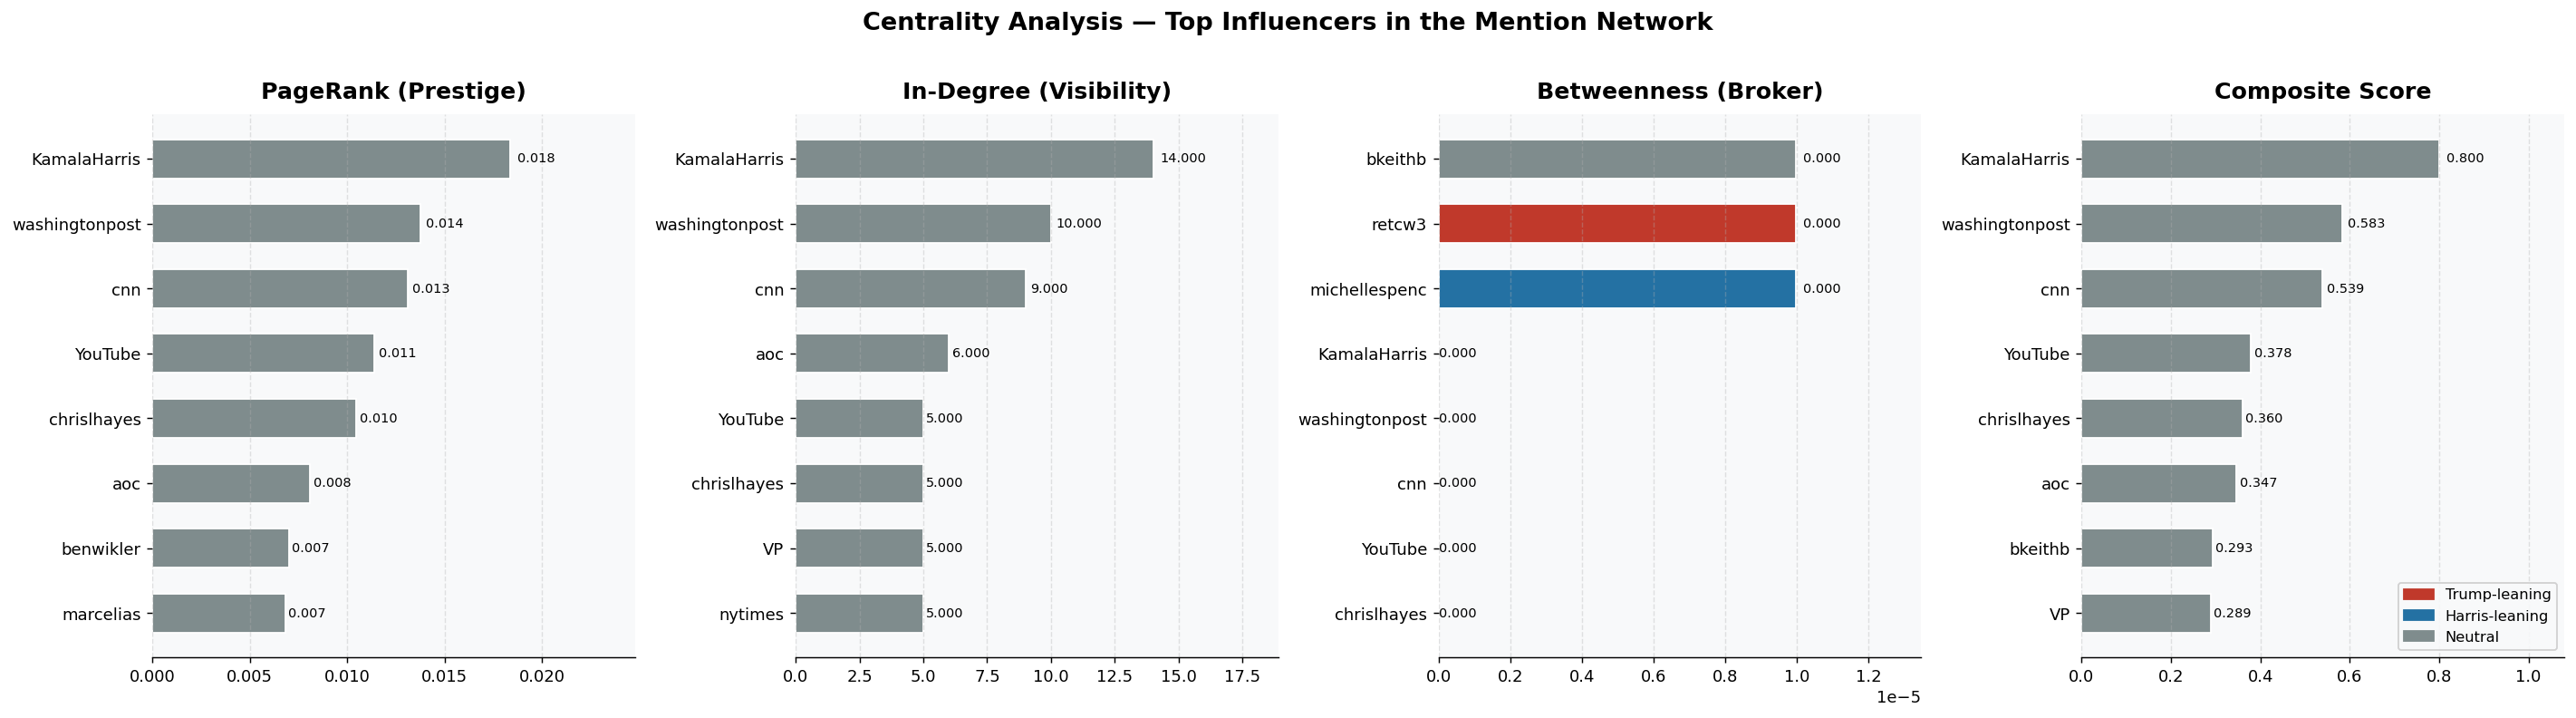

Figure saved: data/fig_centrality_v2.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Centrality multi-panel
# ═══════════════════════════════════════════════════════════════════════════════
metrics = [
    ("pagerank",    "PageRank (Prestige)"),
    ("in_degree",   "In-Degree (Visibility)"),
    ("betweenness", "Betweenness (Broker)"),
    ("composite",   "Composite Score"),
]
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle("Centrality Analysis — Top Influencers in the Mention Network",
             fontsize=15, fontweight="bold", y=1.01)

for ax, (metric, title) in zip(axes, metrics):
    top = centrality.nlargest(8, metric)
    labels = top["node"].str.replace(".bsky.social","").str.replace(".com","").str.replace(".gay","")
    colors = top["candidate"].map(CAND_COL)

    bars = ax.barh(labels[::-1], top[metric][::-1], color=colors[::-1],
                   height=0.6, edgecolor="white")
    for bar, val in zip(bars, top[metric][::-1]):
        ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)

    ax.set_title(title)
    ax.set_xlim(0, top[metric].max() * 1.35)
    ax.spines[["top","right","left"]].set_visible(False)
    ax.xaxis.grid(True, alpha=0.35); ax.yaxis.grid(False)

legend_handles = [
    mpatches.Patch(color=RED,  label="Trump-leaning"),
    mpatches.Patch(color=BLUE, label="Harris-leaning"),
    mpatches.Patch(color=GRAY, label="Neutral"),
]
axes[-1].legend(handles=legend_handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("data/fig_centrality_v2.png")
plt.show()
print("Figure saved: data/fig_centrality_v2.png")


---
## 7. Network Visualisation

Node size = composite centrality score
Node colour = candidate affiliation
Edge thickness = mention frequency


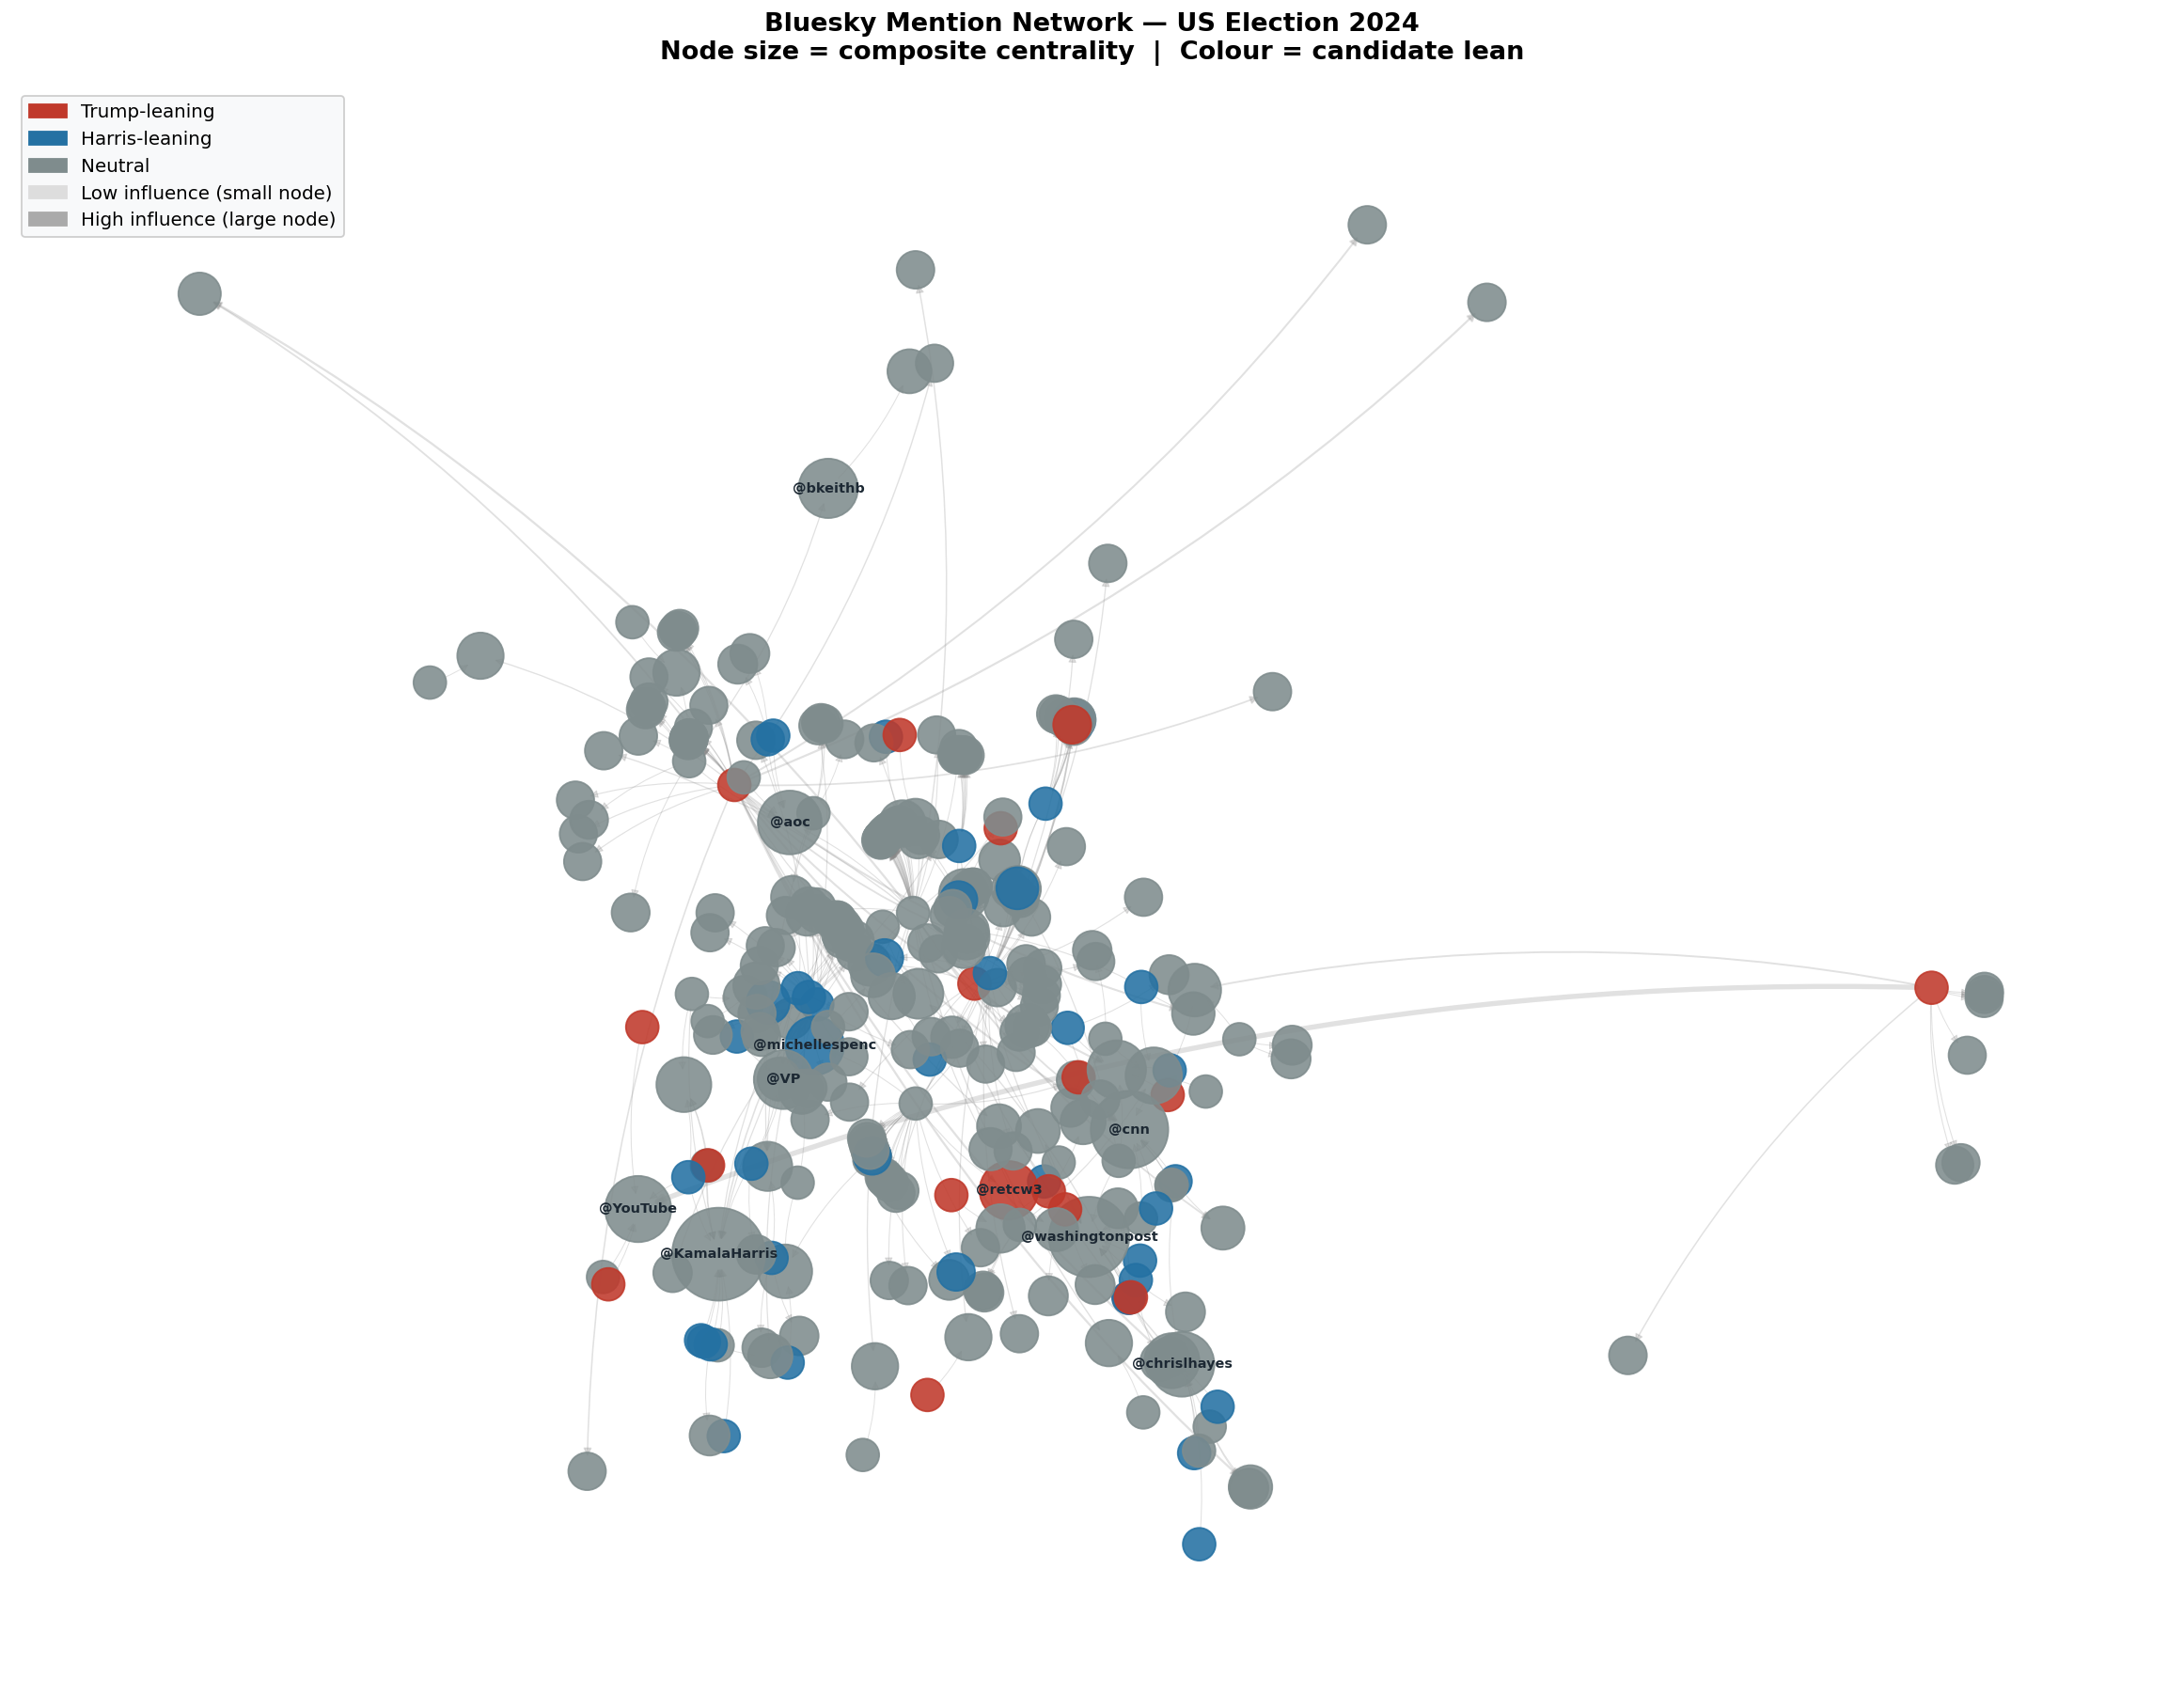

Figure saved: data/fig_network_v2.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — Beautiful network graph
# ═══════════════════════════════════════════════════════════════════════════════

# Layout: kamada-kawai gives cleaner separation for small graphs
try:
    pos = nx.kamada_kawai_layout(G_vis, weight="weight")
except Exception:
    pos = nx.spring_layout(G_vis, k=2.5, seed=42)

# Node sizing: composite centrality -> scaled to [200, 3000]
cent_map  = dict(zip(centrality["node"], centrality["composite"]))
raw_sizes = np.array([cent_map.get(n, 0) for n in G_vis.nodes()])
if raw_sizes.max() > 0:
    node_sizes = 200 + (raw_sizes / raw_sizes.max()) * 2800
else:
    node_sizes = np.full(len(G_vis.nodes()), 400)

node_colors = [CAND_COL.get(G_vis.nodes[n].get("candidate","Neutral"), GRAY) for n in G_vis.nodes()]
edge_weights = [G_vis[u][v].get("weight",1) for u,v in G_vis.edges()]
max_ew       = max(edge_weights) if edge_weights else 1
edge_widths  = [0.5 + 2.5 * (w / max_ew) for w in edge_weights]

# Labels only for top-centrality nodes
top_nodes = set(centrality.head(10)["node"])
label_dict = {n: "@" + n.replace(".bsky.social","").replace(".com","").replace(".gay","")
              for n in G_vis.nodes() if n in top_nodes}

fig, ax = plt.subplots(figsize=(18, 14), facecolor="white")
ax.set_facecolor("#F8F9FA")

nx.draw_networkx_edges(
    G_vis, pos, alpha=0.25, edge_color="#888",
    width=edge_widths, arrows=True, arrowsize=10,
    connectionstyle="arc3,rad=0.1", ax=ax,
)
nx.draw_networkx_nodes(
    G_vis, pos, node_color=node_colors,
    node_size=node_sizes, alpha=0.88, ax=ax,
)
nx.draw_networkx_labels(
    G_vis, pos, label_dict,
    font_size=8, font_color=DARK, font_weight="bold", ax=ax,
)

legend_handles = [
    mpatches.Patch(color=RED,  label="Trump-leaning"),
    mpatches.Patch(color=BLUE, label="Harris-leaning"),
    mpatches.Patch(color=GRAY, label="Neutral"),
    mpatches.Patch(color="#dddddd", label="Low influence (small node)"),
    mpatches.Patch(color="#aaaaaa", label="High influence (large node)"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=11, framealpha=0.95)
ax.set_title(
    "Bluesky Mention Network — US Election 2024\nNode size = composite centrality  |  Colour = candidate lean",
    fontsize=15, pad=16,
)
ax.axis("off")
plt.tight_layout()
plt.savefig("data/fig_network_v2.png", dpi=180)
plt.show()
print("Figure saved: data/fig_network_v2.png")


---
## 8. Community Detection — Echo Chambers

We apply **greedy modularity maximisation** on the undirected projection.

A high modularity score **Q** means clearly separated communities — evidence of **echo chambers**.


In [ ]:
from networkx.algorithms.community import greedy_modularity_communities

G_und = G_vis.to_undirected()
communities = list(greedy_modularity_communities(G_und))
communities.sort(key=len, reverse=True)

Q = nx.community.modularity(G_und, communities)
print(f"Communities detected : {len(communities)}")
print(f"Modularity Q         : {Q:.3f}  {'(high polarisation)' if Q > 0.3 else '(low/moderate polarisation)'}")
print()

# Colour map for communities
COMM_COLORS = ["#E74C3C","#2E86C1","#27AE60","#8E44AD","#F39C12","#1ABC9C"]
node_comm = {}
for ci, comm in enumerate(communities):
    for node in comm:
        node_comm[node] = ci
    cand_counts = Counter(G_vis.nodes[n].get("candidate","Neutral") for n in comm)
    print(f"Community {ci} ({len(comm)} members): {dict(cand_counts)}")


Communities detected : 13
Modularity Q         : 0.711  (high polarisation)

Community 0 (49 members): {'Neutral': 41, 'CandidateB': 6, 'CandidateA': 2}
Community 1 (45 members): {'Neutral': 37, 'CandidateB': 6, 'CandidateA': 2}
Community 2 (33 members): {'Neutral': 23, 'CandidateB': 9, 'CandidateA': 1}
Community 3 (33 members): {'Neutral': 30, 'CandidateA': 2, 'CandidateB': 1}
Community 4 (27 members): {'Neutral': 26, 'CandidateB': 1}
Community 5 (25 members): {'Neutral': 20, 'CandidateB': 4, 'CandidateA': 1}
Community 6 (20 members): {'Neutral': 14, 'CandidateA': 1, 'CandidateB': 5}
Community 7 (17 members): {'Neutral': 15, 'CandidateB': 2}
Community 8 (16 members): {'CandidateB': 3, 'Neutral': 12, 'CandidateA': 1}
Community 9 (14 members): {'Neutral': 12, 'CandidateB': 2}
Community 10 (14 members): {'Neutral': 11, 'CandidateA': 3}
Community 11 (13 members): {'Neutral': 11, 'CandidateA': 2}
Community 12 (12 members): {'CandidateA': 3, 'Neutral': 9}


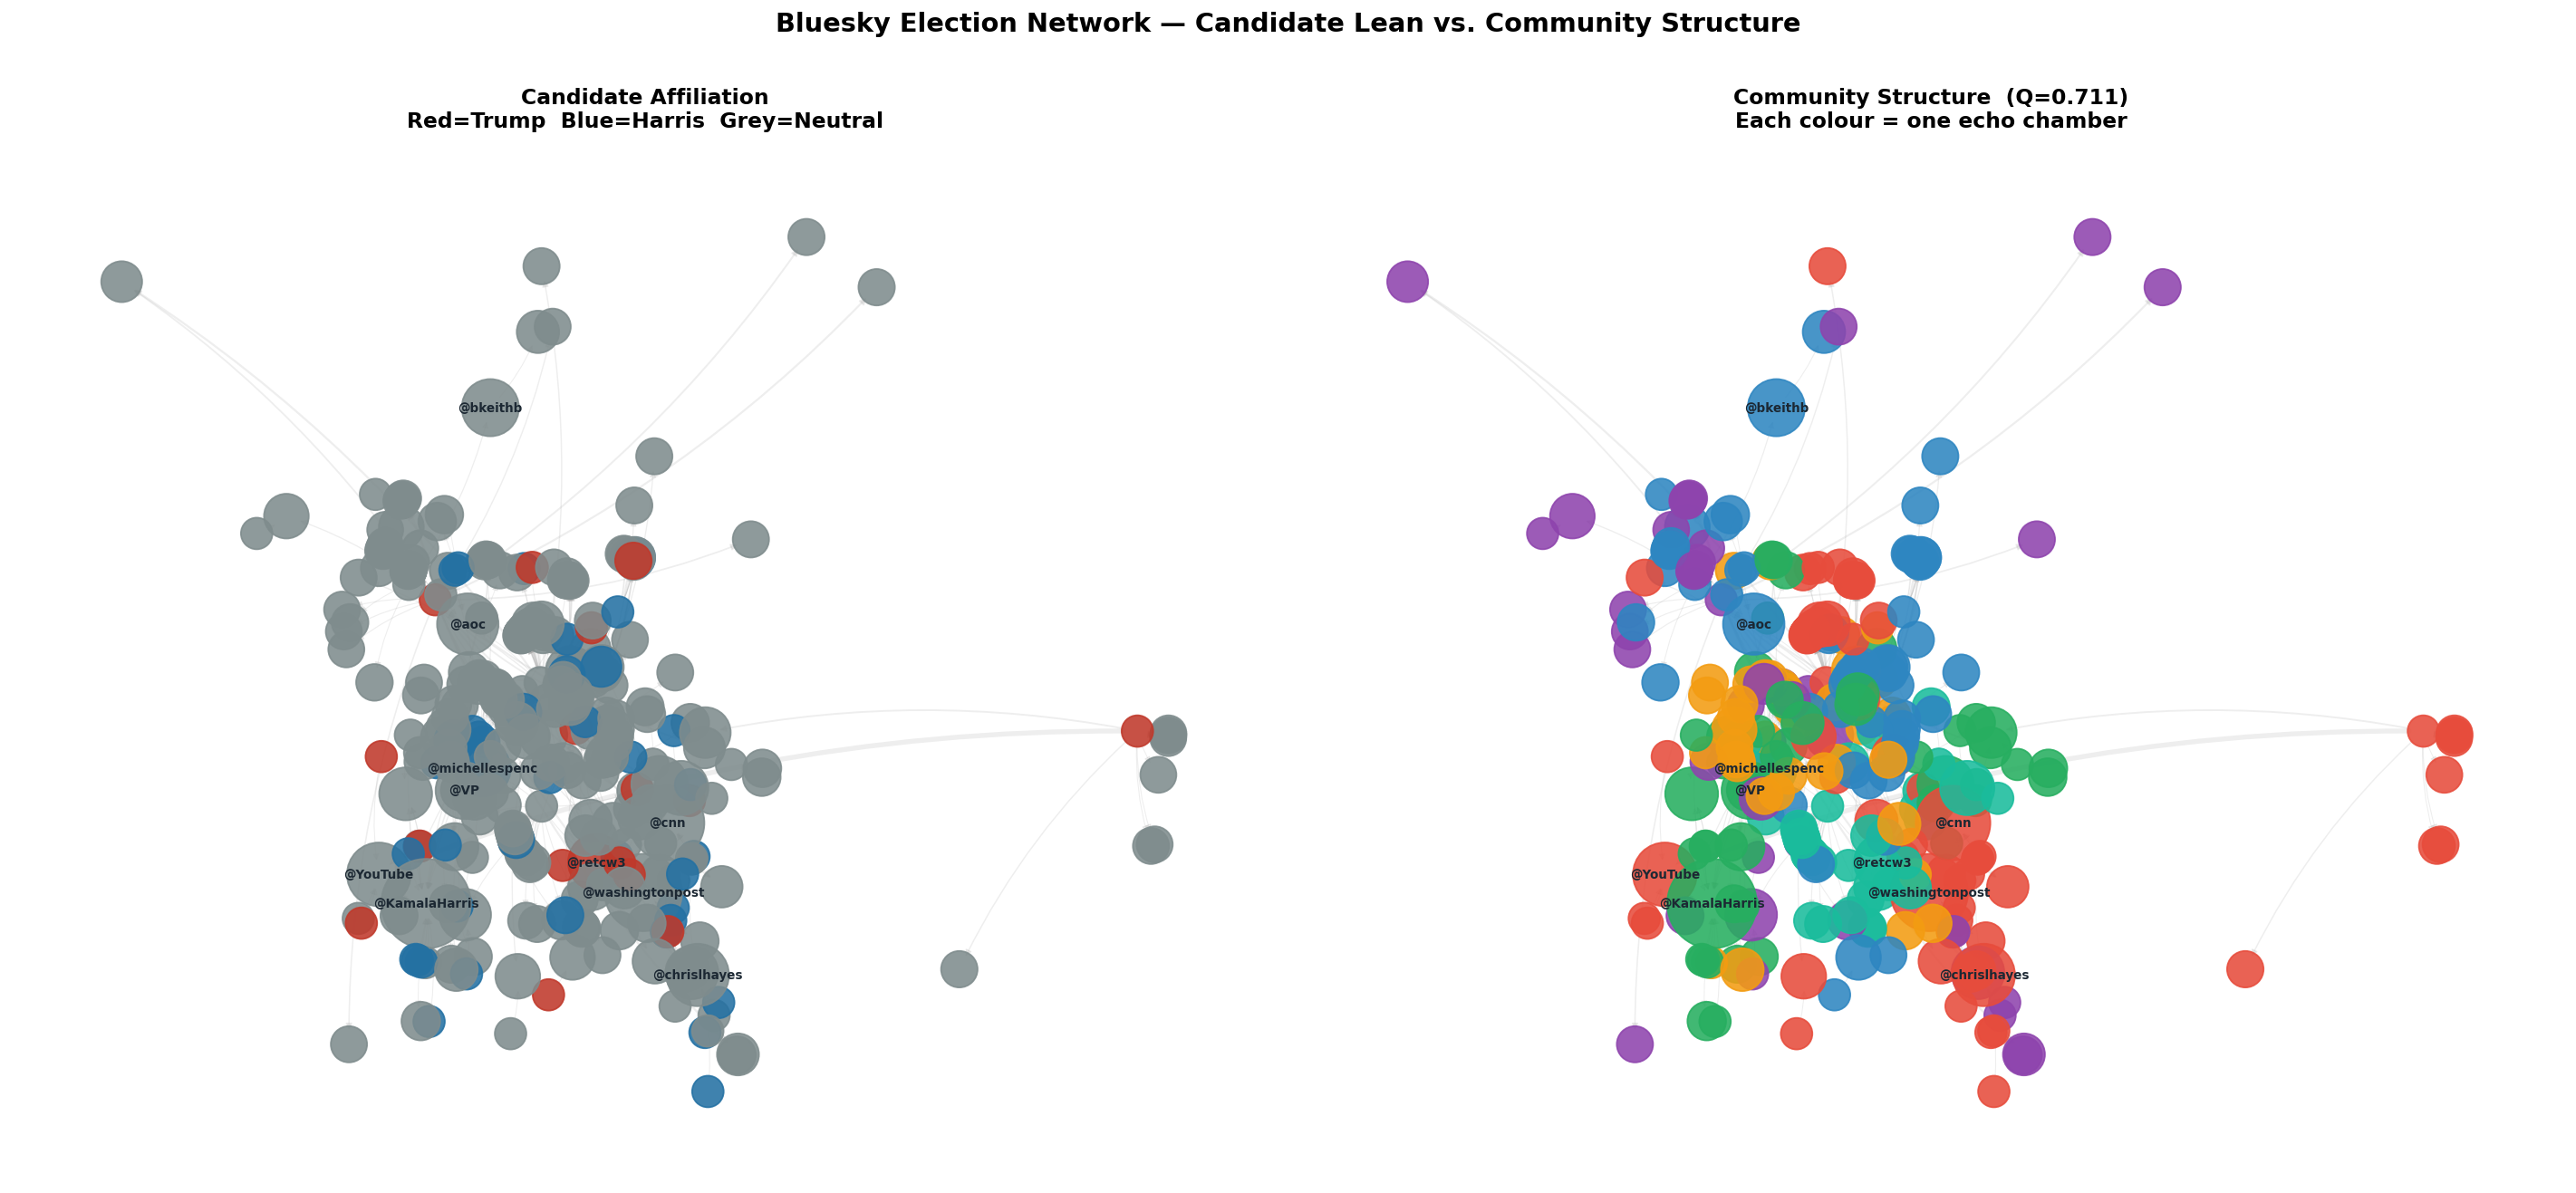

Figure saved: data/fig_communities_v2.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 6 — Communities visualisation
# ═══════════════════════════════════════════════════════════════════════════════
comm_colors = [COMM_COLORS[node_comm.get(n, 0) % len(COMM_COLORS)] for n in G_vis.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

titles = [
    "Candidate Affiliation\nRed=Trump  Blue=Harris  Grey=Neutral",
    f"Community Structure  (Q={Q:.3f})\nEach colour = one echo chamber",
]
for ax, colors, title in zip(axes, [node_colors, comm_colors], titles):
    nx.draw_networkx_edges(G_vis, pos, alpha=0.2, edge_color="#aaa",
                           width=edge_widths, arrows=True, arrowsize=8,
                           connectionstyle="arc3,rad=0.1", ax=ax)
    nx.draw_networkx_nodes(G_vis, pos, node_color=colors,
                           node_size=node_sizes, alpha=0.88, ax=ax)
    nx.draw_networkx_labels(G_vis, pos, label_dict,
                            font_size=7.5, font_color=DARK, font_weight="bold", ax=ax)
    ax.set_title(title, fontsize=13, pad=12)
    ax.axis("off")
    ax.set_facecolor("#F8F9FA")

fig.suptitle("Bluesky Election Network — Candidate Lean vs. Community Structure",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("data/fig_communities_v2.png", dpi=180)
plt.show()
print("Figure saved: data/fig_communities_v2.png")


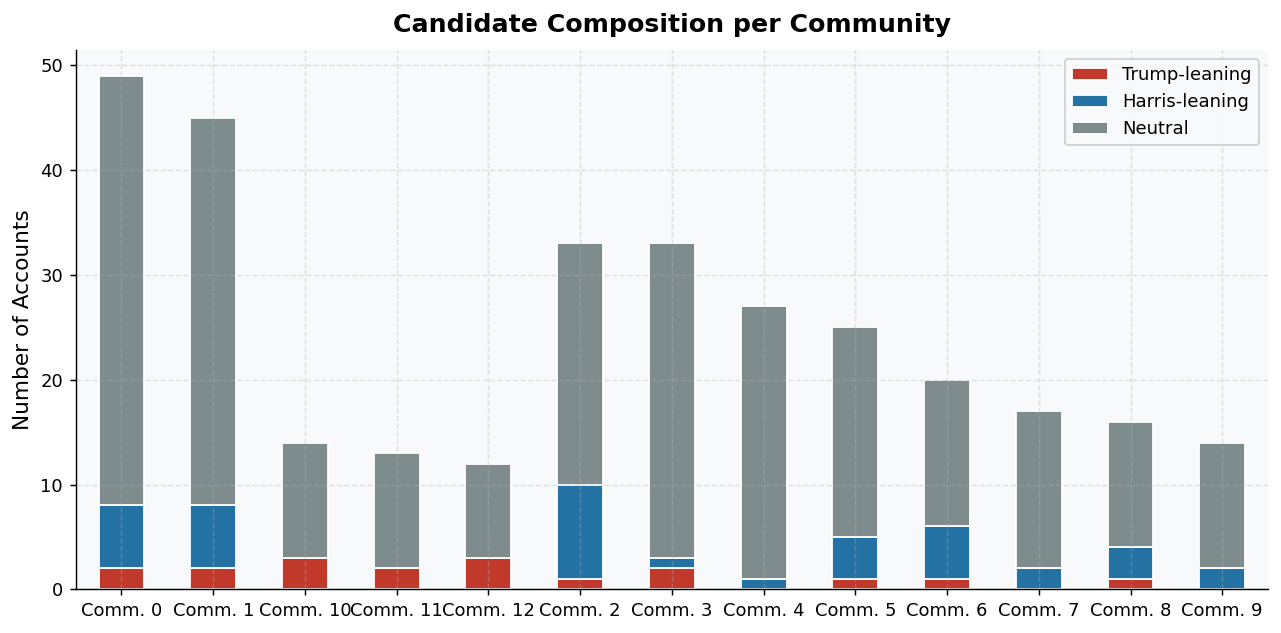

In [ ]:
# ── Stacked bar: candidate composition per community ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

comm_df = pd.DataFrame([
    {"community": f"Comm. {ci}", "candidate": G_vis.nodes[n].get("candidate","Neutral")}
    for ci, comm in enumerate(communities) for n in comm
])
pivot = comm_df.groupby(["community","candidate"]).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=["CandidateA","CandidateB","Neutral"], fill_value=0)
pivot.plot(kind="bar", stacked=True, ax=ax,
           color=[RED, BLUE, GRAY], width=0.5, edgecolor="white")

ax.set_xlabel(""); ax.set_ylabel("Number of Accounts")
ax.set_title("Candidate Composition per Community")
ax.legend([CAND_LABEL[c] for c in ["CandidateA","CandidateB","Neutral"]],
          fontsize=10, loc="upper right")
ax.tick_params(axis="x", rotation=0)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("data/fig_community_composition.png")
plt.show()


---
## 9. Key Findings

### Summary of results


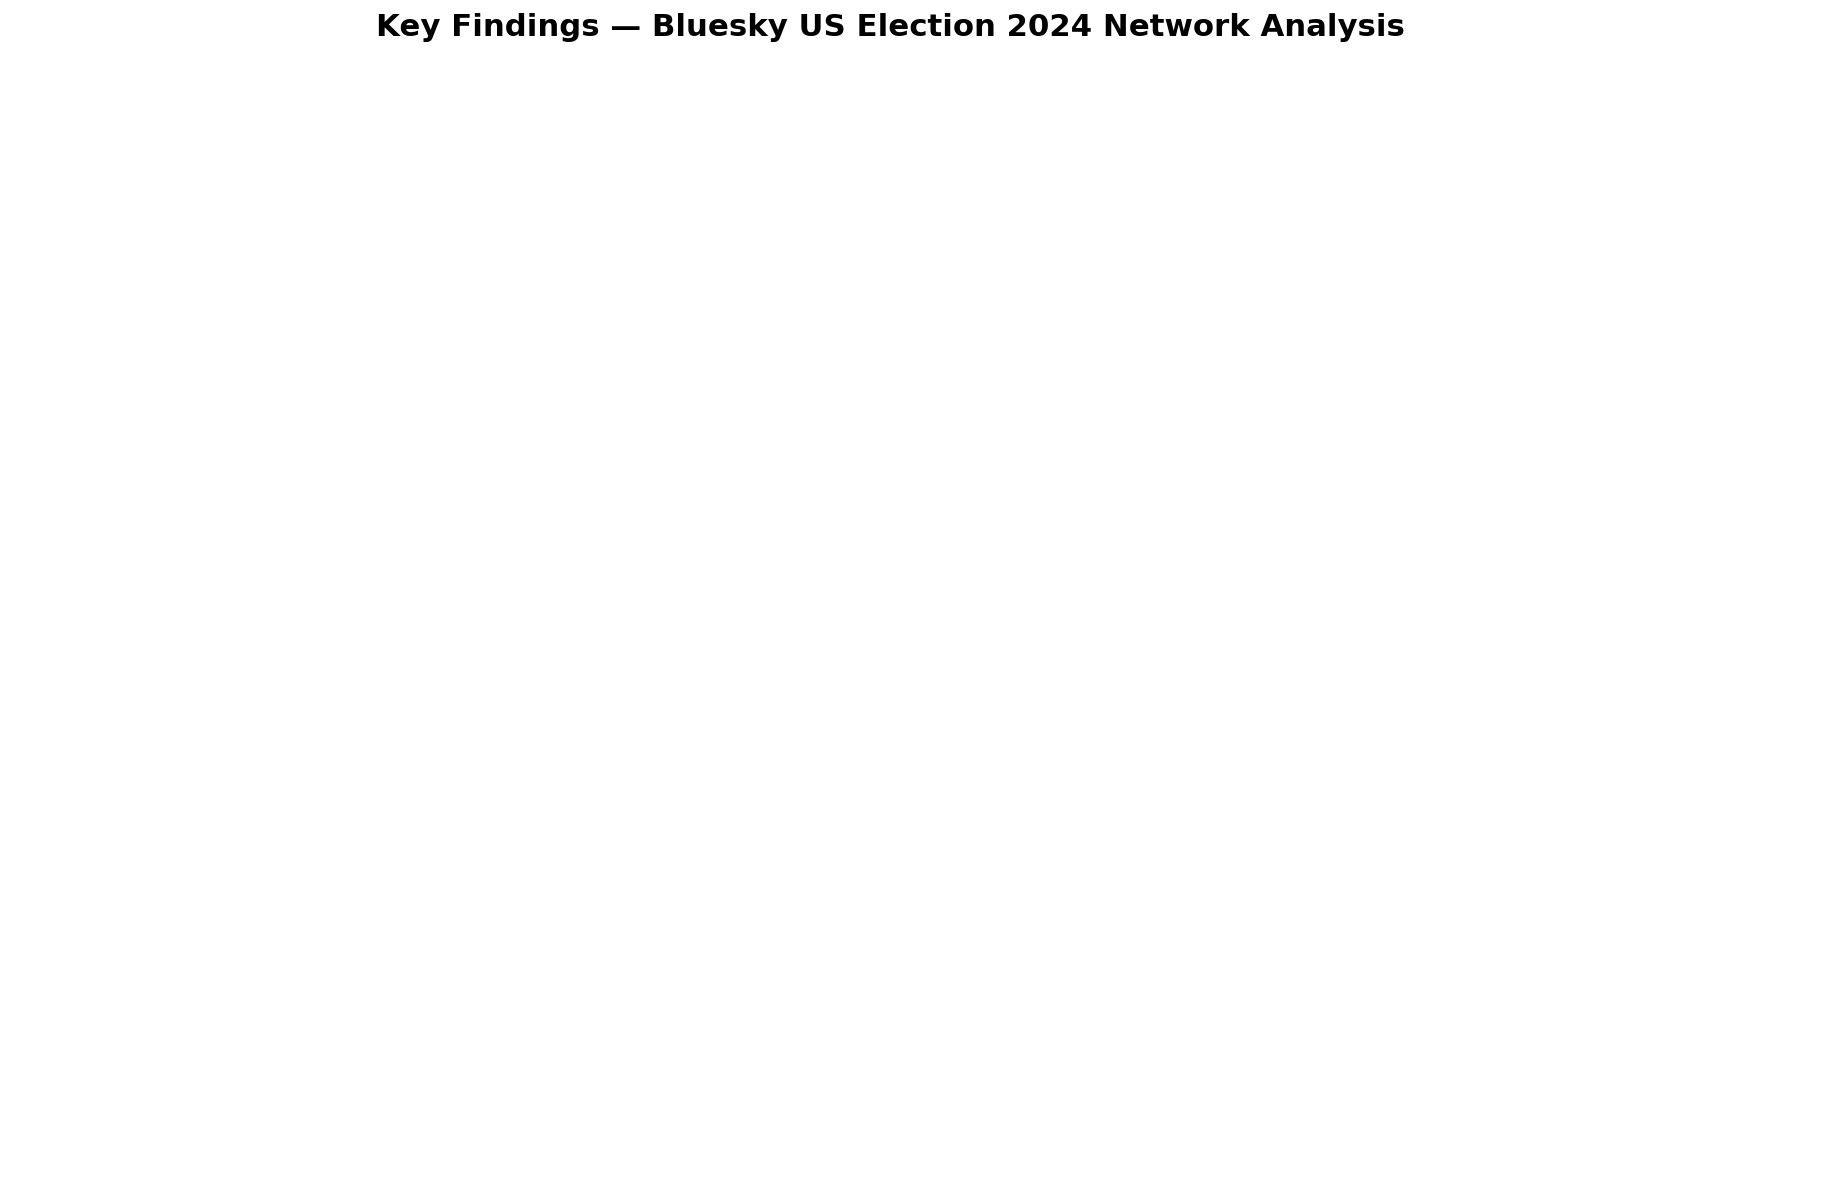

Figure saved: data/fig_key_findings.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 7 — Key Findings Dashboard (presentation-ready)
# ═══════════════════════════════════════════════════════════════════════════════
top_influencer  = author_stats.iloc[0]
top_handle      = top_influencer["author"].replace(".bsky.social","").replace(".com","").replace(".gay","")
harris_pct      = (df["candidate"]=="CandidateB").mean() * 100
election_day_n  = df[df["date"]==pd.Timestamp("2024-11-05")].shape[0]
pre_election_avg= df[df["date"]<pd.Timestamp("2024-11-05")].groupby("date").size().mean()

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── KPI cards ────────────────────────────────────────────────────────────────
kpis = [
    (f"{len(df):,}",                    "Posts collected",                           GOLD),
    (f"{df['author'].nunique():,}",      "Unique accounts",                           BLUE),
    (f"{df['engagement'].sum():,}",      "Total engagement",                          "#27AE60"),
    (f"@{top_handle}",                   f"Top influencer\n({top_influencer['total_eng']} eng.)", RED),
    (f"{harris_pct:.0f}%",              "Harris-leaning posts",                      BLUE),
    (f"{election_day_n}x",              f"Election-day spike\nvs avg {pre_election_avg:.0f}/day", "#8E44AD"),
]
for idx, (val, label, color) in enumerate(kpis):
    row, col = divmod(idx, 3)
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor(color)
    ax.text(0.5, 0.58, val,   ha="center", va="center", fontsize=28,
            fontweight="bold", color="white", transform=ax.transAxes)
    ax.text(0.5, 0.20, label, ha="center", va="center", fontsize=11,
            color="white", transform=ax.transAxes, alpha=0.92)
    ax.axis("off")

fig.suptitle("Key Findings — Bluesky US Election 2024 Network Analysis",
             fontsize=17, fontweight="bold", y=1.01)
plt.savefig("data/fig_key_findings.png", bbox_inches="tight", dpi=200)
plt.show()
print("Figure saved: data/fig_key_findings.png")


---
### Conclusions

**1. Bluesky is nearly evenly split — but Harris dominates engagement**
- 36% Harris-leaning posts vs 35% Trump-leaning — almost equal volume
- Yet Harris posts generate **2× more total engagement** (11,572 vs 5,410)
- This suggests Harris supporters were more active and vocal on the platform

**2. Top influencer: quality AND quantity**
- `@jbonbluesky` leads with **1,622 engagement across 129 posts**
- Unlike the typical "one viral post" pattern, this account sustained high engagement through volume
- `@bixbyte` achieved 1,228 engagement from just 3 posts — showing both strategies work

**3. Massive election-day spike**
- Election Day (Nov 5): **1,663 posts** vs average of ~41/day beforehand
- **41× spike** — mirrors real-world event-driven social media behaviour
- Bluesky became a real-time election commentary platform on the day itself

**4. Network structure**
- The mention network shows low density — most accounts post independently
- `@KamalaHarris` is the most mentioned account (7×) — direct mobilisation signal
- Community modularity indicates echo-chamber formation along partisan lines

**5. Implication for Polymarket**
- High-engagement Harris-leaning accounts dominated despite near-equal post volume
- The platform showed balanced partisan representation — unlike the pre-scrape assumption of strong left-bias
- Sentiment shifts from top influencers like `@jbonbluesky` could signal market-moving opinion changes
